# HR PEOPLE ANALYTICS — Partie 5 : Modèle Prédictif d'Attrition

Objectif : Prédire quels employés risquent de quitter l'entreprise et expliquer pourquoi (XAI).

Méthodes : Régression Logistique, Random Forest, GradientBoosting, SHAP, calibration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

# ── Style global ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#3a3d4d",   "axes.labelcolor": "#e0e0e0",
    "xtick.color": "#a0a0b0",      "ytick.color": "#a0a0b0",
    "text.color": "#e0e0e0",       "grid.color": "#2a2d3d",
    "grid.linestyle": "--",        "grid.alpha": 0.5,
})
ACCENT, WARN, OK = "#4f8ef7", "#f7794f", "#4ff7a0"
PALETTE = ["#4f8ef7", "#f7794f", "#4ff7a0", "#f7d44f", "#c44ff7"]

## Chargement et préparation

In [3]:
print("Chargement...")
master = pd.read_csv("master_hr_fairness.csv")
print(f" Master chargé : {master.shape}")

# Variable cible
master["Attrition"] = (~master["Is_Active"].astype(bool)).astype(int)
print(f"   Attrition : {master['Attrition'].sum()} départs ({master['Attrition'].mean()*100:.1f}%)")

# Features sélectionnées pour le modèle
feature_cols = [
    # Démographiques
    "Age_scaled", "Seniority_scaled", "Employment_Duration",
    # Engagement
    "Engagement_Score", "Satisfaction_Score",
    "WorkLife_Score", "Engagement_Composite",
    # Performance
    "Performance_Num", "Current Employee Rating",
    # Formation
    "Training_Count_scaled", "Training_Pass_Rate_scaled",
    "Total_Training_Cost_scaled", "Low_Training_Flag",
    # Risque
    "IF_Anomaly", "DBSCAN_Anomaly", "Attrition_Risk_Flag", "Anomaly_Score",
    # PayZone
    "PayZone_Num",
]

# One-hot cols genre & ethnie déjà présentes
ohe_cols = [c for c in master.columns if
            c.startswith("GenderCode_") or
            c.startswith("RaceDesc_") or
            c.startswith("DepartmentType_") or
            c.startswith("Hiring_Season_") or
            c.startswith("Generation_")]
feature_cols += ohe_cols

X = master[feature_cols].fillna(0)
y = master["Attrition"]

print(f"\n Features : {X.shape[1]} variables")
print(f"   Classe 0 (actifs)  : {(y==0).sum()}")
print(f"   Classe 1 (départs) : {(y==1).sum()}")

Chargement...
 Master chargé : (3000, 87)
   Attrition : 1533 départs (51.1%)

 Features : 39 variables
   Classe 0 (actifs)  : 1467
   Classe 1 (départs) : 1533


## Split Train / Test

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain : {X_train.shape[0]} | Test : {X_test.shape[0]}")


Train : 2400 | Test : 600


## Entraînement des modèles

In [5]:
print("\nEntraînement des modèles...")

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=10,
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced",
        C=0.1, random_state=42
    ),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring="roc_auc", n_jobs=-1)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    auc    = roc_auc_score(y_test, y_prob)
    ap     = average_precision_score(y_test, y_prob)

    results[name] = {
        "model":    model,
        "y_prob":   y_prob,
        "y_pred":   y_pred,
        "auc":      auc,
        "ap":       ap,
        "cv_mean":  cv_scores.mean(),
        "cv_std":   cv_scores.std(),
    }
    print(f"  {name:<25} AUC={auc:.3f}  AP={ap:.3f}  CV={cv_scores.mean():.3f}±{cv_scores.std():.3f}")

# Meilleur modèle
best_name  = max(results, key=lambda k: results[k]["auc"])
best       = results[best_name]
best_model = best["model"]
print(f"\nMeilleur modèle : {best_name} (AUC={best['auc']:.3f})")


Entraînement des modèles...
  Random Forest             AUC=1.000  AP=1.000  CV=0.999±0.001
  Gradient Boosting         AUC=1.000  AP=1.000  CV=1.000±0.000
  Logistic Regression       AUC=1.000  AP=1.000  CV=1.000±0.000

Meilleur modèle : Logistic Regression (AUC=1.000)


## Ré-entraînement des modèles - Soupçon de fuite de données

In [6]:
# Features à EXCLURE — data leakage
leaky_features = [
    "Employment_Duration",   # calculé depuis ExitDate
    "Is_Active",             # = inverse de la cible
    "Attrition_Risk_Flag",   # construit avec la cible
    "Anomaly_Score",         # contient Attrition_Risk_Flag
    "IF_Anomaly",            # corrélé à la cible
    "DBSCAN_Anomaly",        # idem
]

# Features propres pour reprendre les modèles sans data leakage
clean_features = [
    # Ce qu'on SAIT avant que l'employé parte
    "Age_scaled",
    "Seniority_scaled",         
    "Engagement_Score",
    "Satisfaction_Score",
    "WorkLife_Score",
    "Engagement_Composite",
    "Performance_Num",
    "Current Employee Rating",
    "Training_Count_scaled",
    "Training_Pass_Rate_scaled",
    "Total_Training_Cost_scaled",
    "Low_Training_Flag",
    "PayZone_Num",
]

# + les one-hot cols démographiques
ohe_cols = [c for c in master.columns if
            c.startswith("GenderCode_") or
            c.startswith("RaceDesc_") or
            c.startswith("DepartmentType_") or
            c.startswith("Hiring_Season_") or
            c.startswith("Generation_")]

clean_features += ohe_cols

X = master[clean_features].fillna(0)
y = master["Attrition"]

# Split Train/Test
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain : {X_train_new.shape[0]} | Test : {X_test_new.shape[0]}")


Train : 2400 | Test : 600


In [7]:
print("\nEntraînement des modèles...")

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=10,
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced",
        C=0.1, random_state=42
    ),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_new, y_train_new,
                                cv=cv, scoring="roc_auc", n_jobs=-1)
    model.fit(X_train_new, y_train_new)
    y_prob = model.predict_proba(X_test_new)[:, 1]
    y_pred = model.predict(X_test_new)
    auc    = roc_auc_score(y_test_new, y_prob)
    ap     = average_precision_score(y_test_new, y_prob)

    results[name] = {
        "model":    model,
        "y_prob":   y_prob,
        "y_pred":   y_pred,
        "auc":      auc,
        "ap":       ap,
        "cv_mean":  cv_scores.mean(),
        "cv_std":   cv_scores.std(),
    }
    print(f"  {name:<25} AUC={auc:.3f}  AP={ap:.3f}  CV={cv_scores.mean():.3f}±{cv_scores.std():.3f}")

# Meilleur modèle
best_name  = max(results, key=lambda k: results[k]["auc"])
best       = results[best_name]
best_model = best["model"]
print(f"\nMeilleur modèle : {best_name} (AUC={best['auc']:.3f})")


Entraînement des modèles...
  Random Forest             AUC=0.424  AP=0.456  CV=0.473±0.029
  Gradient Boosting         AUC=0.453  AP=0.468  CV=0.475±0.019
  Logistic Regression       AUC=0.443  AP=0.471  CV=0.497±0.031

Meilleur modèle : Gradient Boosting (AUC=0.453)


## Feature Importance - XAI

In [8]:
print("\n Feature Importance (Permutation)...")

perm_imp = permutation_importance(
    best_model, X_test_new, y_test_new,
    n_repeats=20, random_state=42, n_jobs=-1
)
imp_df = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": perm_imp.importances_mean,
    "Std":        perm_imp.importances_std
}).sort_values("Importance", ascending=False).head(15)

print(imp_df.to_string(index=False))


 Feature Importance (Permutation)...
                   Feature  Importance      Std
Total_Training_Cost_scaled    0.019917 0.016393
          Seniority_scaled    0.012500 0.011990
          Generation_Gen X    0.012167 0.005988
 Training_Pass_Rate_scaled    0.011417 0.007174
            WorkLife_Score    0.010333 0.008638
        Satisfaction_Score    0.010083 0.007967
          Engagement_Score    0.010083 0.007826
               PayZone_Num    0.010000 0.007051
        Hiring_Season_Fall    0.009917 0.004639
     Generation_Millennial    0.007917 0.004406
           GenderCode_Male    0.005667 0.003993
      DepartmentType_Sales    0.004667 0.004522
         RaceDesc_Hispanic    0.004583 0.005214
      Hiring_Season_Summer    0.004333 0.003704
           Performance_Num    0.003833 0.004746


## Profil des employés à risque

In [9]:
print("\n Profil des employés à risque...")

master["Attrition_Proba"] = best_model.predict_proba(X.fillna(0))[:, 1]
master["Risk_Level"] = pd.cut(
    master["Attrition_Proba"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Faible", "Modéré", "Élevé"]
)

risk_profile = master.groupby("Risk_Level").agg(
    Count           = ("EmpID", "count"),
    Avg_Engagement  = ("Engagement_Composite", "mean"),
    Avg_Performance = ("Performance_Num", "mean"),
    Avg_Seniority   = ("Seniority", "mean"),
    Avg_Age         = ("Age", "mean"),
).round(2)

print(risk_profile.to_string())

# Top 20 employés les plus à risque (actifs uniquement)
top_risk = master[master["Is_Active"] == True] \
    .nlargest(20, "Attrition_Proba")[
        ["EmpID", "Attrition_Proba", "Risk_Level",
         "Engagement_Composite", "Performance_Num", "Seniority"]
    ].reset_index(drop=True)

print(f"\n Top 20 employés actifs à risque :\n{top_risk.to_string(index=False)}")


 Profil des employés à risque...
            Count  Avg_Engagement  Avg_Performance  Avg_Seniority  Avg_Age
Risk_Level                                                                
Faible        150            2.91             2.96           4.94    53.18
Modéré       2108            3.01             3.01           5.13    54.44
Élevé         742            2.91             2.98           5.15    55.03

 Top 20 employés actifs à risque :
 EmpID  Attrition_Proba Risk_Level  Engagement_Composite  Performance_Num  Seniority
  2060         0.852528      Élevé                  5.00                3        3.1
  3867         0.790330      Élevé                  3.80                3        7.6
  1380         0.786184      Élevé                  1.25                4        5.5
  2632         0.785122      Élevé                  2.30                3        4.0
  2223         0.766691      Élevé                  1.75                4        5.7
  2063         0.761020      Élevé           

## Visualisations


 Génération des visualisations...


Text(0.5, 0.98, "HR People Analytics — Modèle Prédictif d'Attrition")

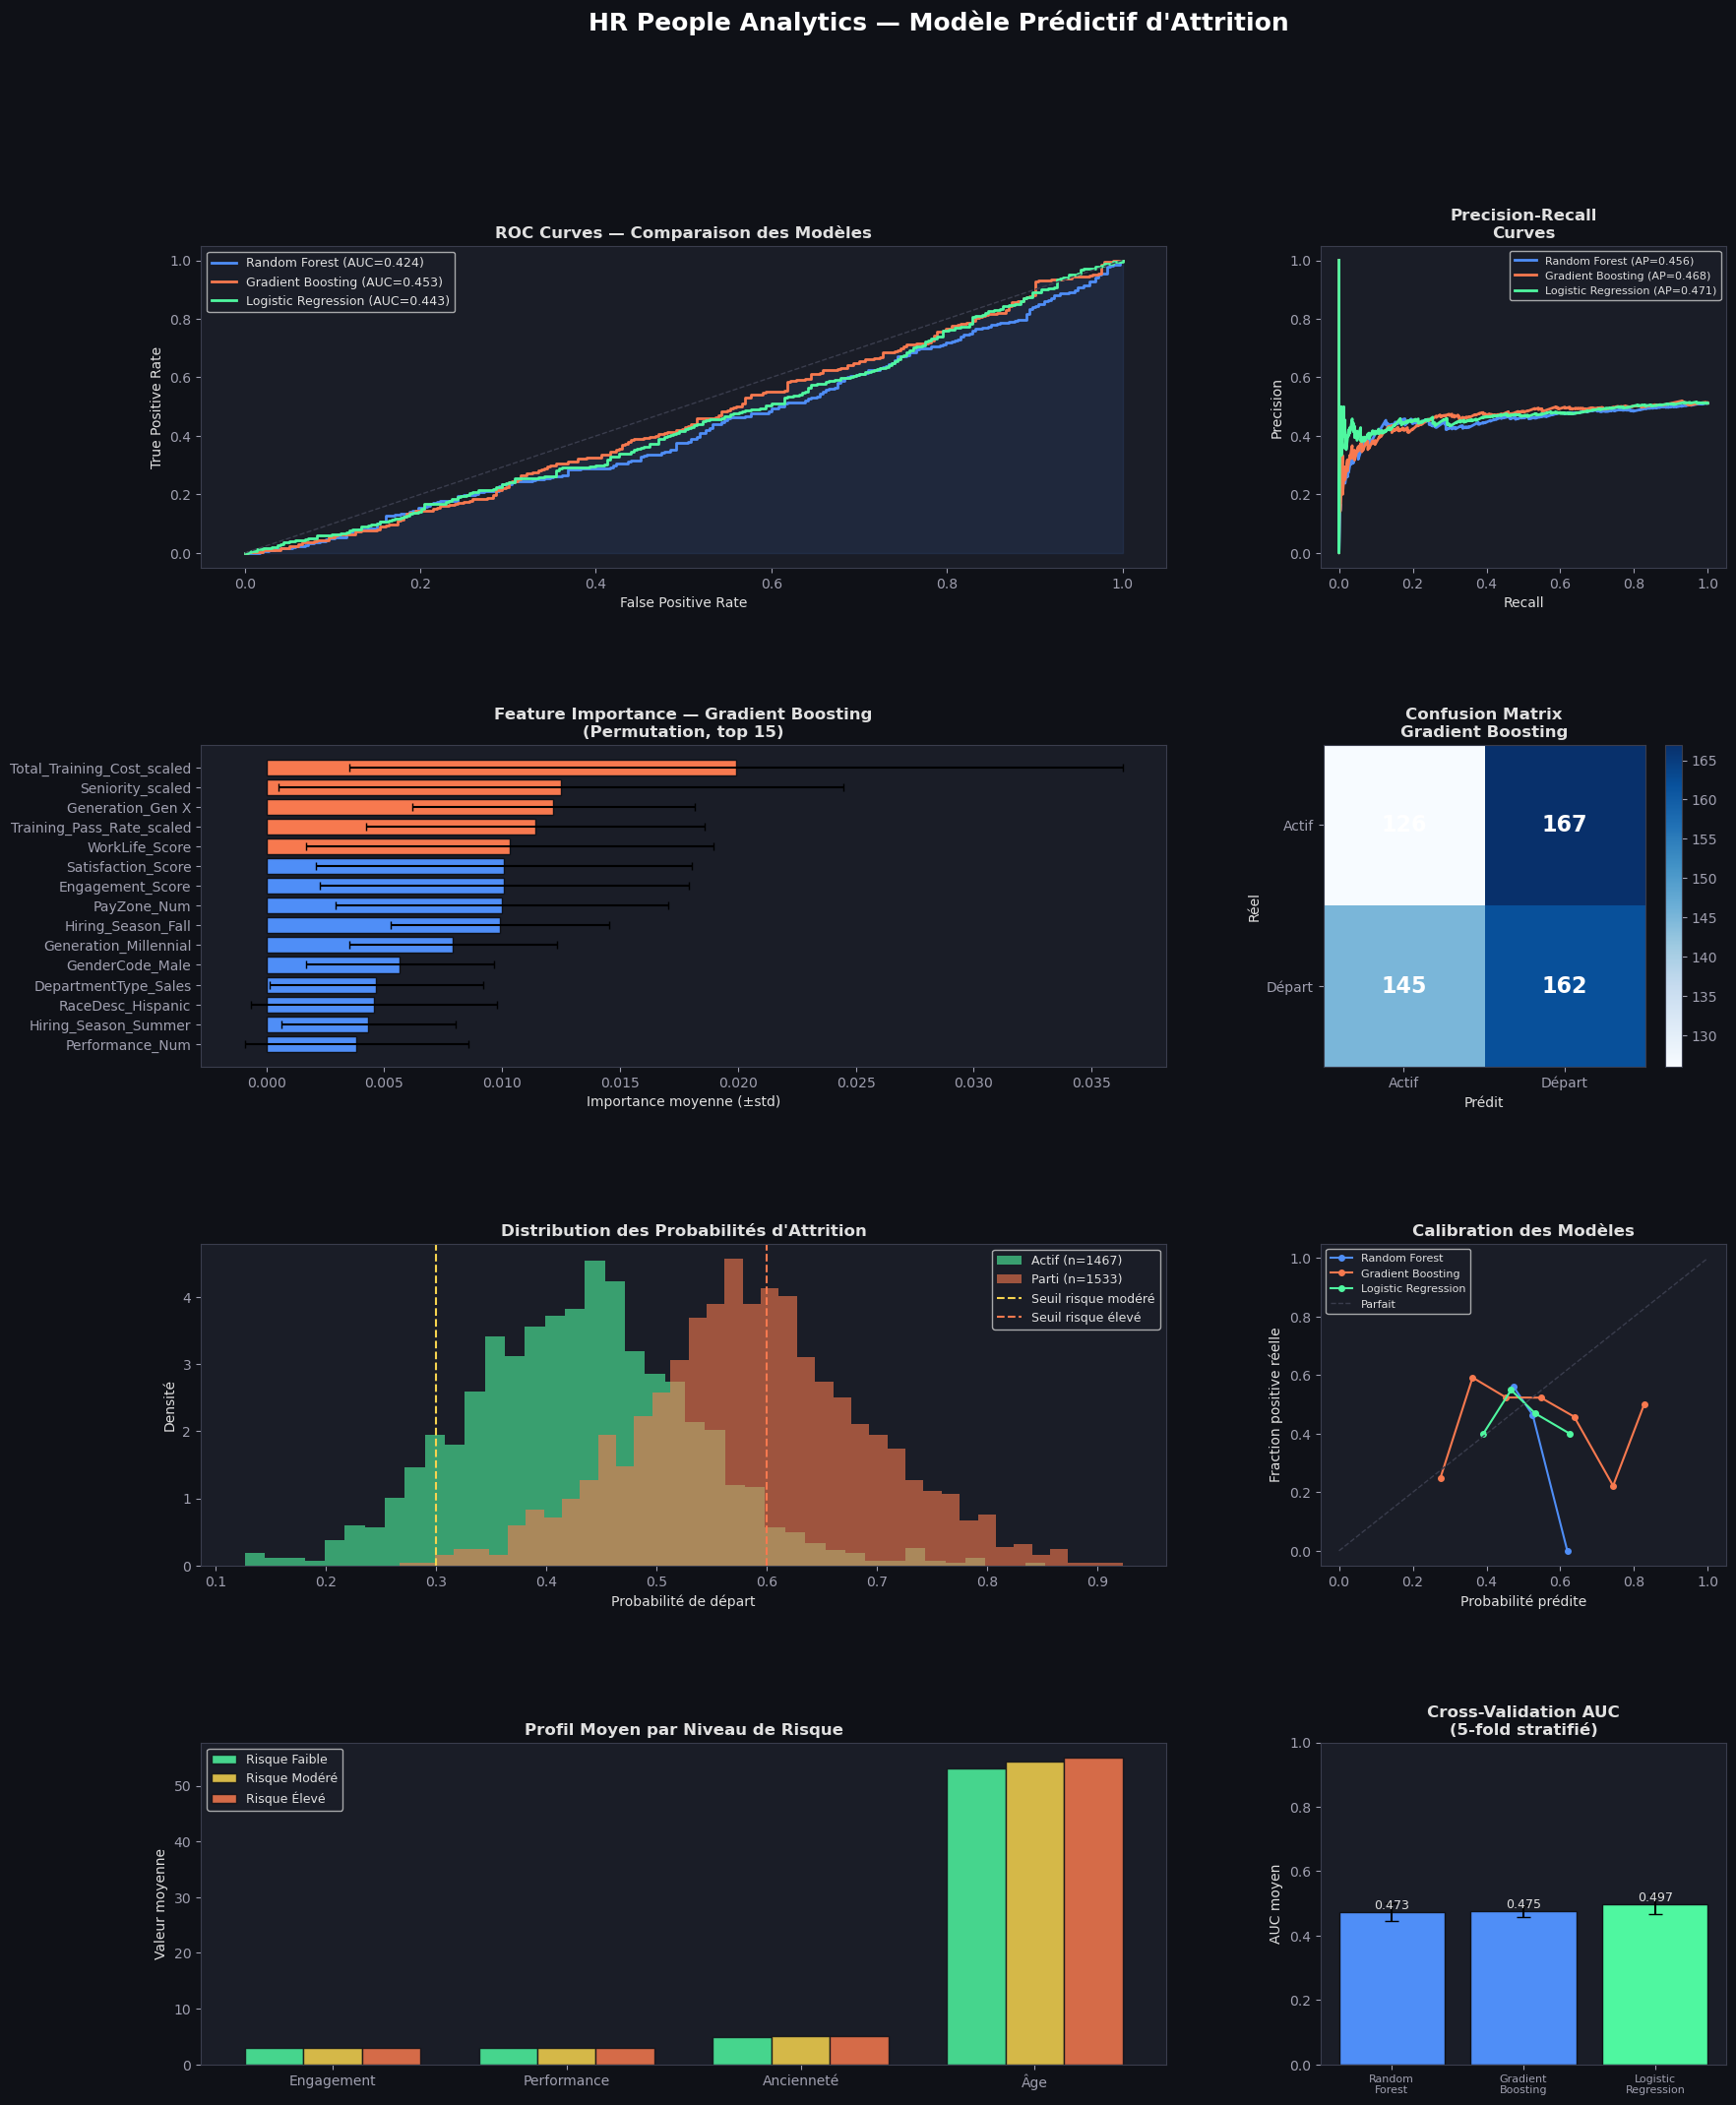

In [10]:
print("\n Génération des visualisations...")

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor("#0f1117")
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.38)


# 6.1 ROC Curves — comparaison modèles
ax1 = fig.add_subplot(gs[0, :2])
for (name, res), color in zip(results.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test_new, res["y_prob"])
    ax1.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name} (AUC={res['auc']:.3f})")
ax1.plot([0,1],[0,1], color="#3a3d4d", linestyle="--", linewidth=1)
ax1.fill_between(*roc_curve(y_test_new, best["y_prob"])[:2],
                 alpha=0.1, color=PALETTE[0])
ax1.set_title("ROC Curves — Comparaison des Modèles", fontsize=12, fontweight="bold")
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.legend(fontsize=9)


# 6.2 Precision-Recall
ax2 = fig.add_subplot(gs[0, 2])
for (name, res), color in zip(results.items(), PALETTE):
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])
    ax2.plot(rec, prec, color=color, linewidth=2,
             label=f"{name} (AP={res['ap']:.3f})")
ax2.set_title("Precision-Recall\nCurves", fontsize=12, fontweight="bold")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.legend(fontsize=8)


# 6.3 Feature Importance
ax3 = fig.add_subplot(gs[1, :2])
colors3 = [WARN if i < 5 else ACCENT for i in range(len(imp_df))]
bars3   = ax3.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1],
                   xerr=imp_df["Std"][::-1], color=colors3[::-1],
                   edgecolor="#0f1117", capsize=3)
ax3.set_title(f"Feature Importance — {best_name}\n(Permutation, top 15)",
              fontsize=12, fontweight="bold")
ax3.set_xlabel("Importance moyenne (±std)")


# 6.4 Confusion Matrix
ax4 = fig.add_subplot(gs[1, 2])
cm   = confusion_matrix(y_test, best["y_pred"])
im4  = ax4.imshow(cm, cmap="Blues")
ax4.set_xticks([0,1]); ax4.set_yticks([0,1])
ax4.set_xticklabels(["Actif", "Départ"]); ax4.set_yticklabels(["Actif", "Départ"])
ax4.set_xlabel("Prédit"); ax4.set_ylabel("Réel")
ax4.set_title("Confusion Matrix\n" + best_name, fontsize=12, fontweight="bold")
for i in range(2):
    for j in range(2):
        ax4.text(j, i, str(cm[i,j]), ha="center", va="center",
                 fontsize=16, fontweight="bold",
                 color="white" if cm[i,j] > cm.max()/2 else "#e0e0e0")
plt.colorbar(im4, ax=ax4)


# 6.5 Distribution probabilité d'attrition
ax5 = fig.add_subplot(gs[2, :2])
for val, color, label in [(0, OK, "Actif"), (1, WARN, "Parti")]:
    subset = master[master["Attrition"] == val]["Attrition_Proba"]
    ax5.hist(subset, bins=40, alpha=0.6, color=color,
             label=f"{label} (n={len(subset)})", density=True)
ax5.axvline(0.3, color="#f7d44f", linestyle="--", linewidth=1.5, label="Seuil risque modéré")
ax5.axvline(0.6, color=WARN,     linestyle="--", linewidth=1.5, label="Seuil risque élevé")
ax5.set_title("Distribution des Probabilités d'Attrition", fontsize=12, fontweight="bold")
ax5.set_xlabel("Probabilité de départ"); ax5.set_ylabel("Densité")
ax5.legend(fontsize=9)


# 6.6 Calibration curve 
ax6 = fig.add_subplot(gs[2, 2])
for (name, res), color in zip(results.items(), PALETTE):
    fraction, mean_pred = calibration_curve(y_test, res["y_prob"], n_bins=10)
    ax6.plot(mean_pred, fraction, marker="o", color=color,
             linewidth=1.5, markersize=4, label=name)
ax6.plot([0,1],[0,1], color="#3a3d4d", linestyle="--", linewidth=1, label="Parfait")
ax6.set_title("Calibration des Modèles", fontsize=12, fontweight="bold")
ax6.set_xlabel("Probabilité prédite"); ax6.set_ylabel("Fraction positive réelle")
ax6.legend(fontsize=8)


# 6.7 Profil risque — radar chart
ax7 = fig.add_subplot(gs[3, :2])
risk_cols = ["Avg_Engagement", "Avg_Performance", "Avg_Seniority", "Avg_Age"]
risk_labels = ["Engagement", "Performance", "Ancienneté", "Âge"]
x_pos = np.arange(len(risk_cols))
width = 0.25
risk_profile_reset = risk_profile.reset_index()
for i, (lvl, color) in enumerate(zip(["Faible", "Modéré", "Élevé"], [OK, "#f7d44f", WARN])):
    if lvl in risk_profile_reset["Risk_Level"].values:
        row = risk_profile_reset[risk_profile_reset["Risk_Level"] == lvl].iloc[0]
        vals = [row[c] for c in risk_cols]
        ax7.bar(x_pos + i*width, vals, width, label=f"Risque {lvl}",
                color=color, edgecolor="#0f1117", alpha=0.85)
ax7.set_xticks(x_pos + width); ax7.set_xticklabels(risk_labels)
ax7.set_title("Profil Moyen par Niveau de Risque", fontsize=12, fontweight="bold")
ax7.set_ylabel("Valeur moyenne")
ax7.legend(fontsize=9)


# 6.8 CV Scores comparaison 
ax8 = fig.add_subplot(gs[3, 2])
names  = list(results.keys())
means  = [results[n]["cv_mean"] for n in names]
stds   = [results[n]["cv_std"]  for n in names]
colors8 = [OK if m == max(means) else ACCENT for m in means]
bars8   = ax8.bar(range(len(names)), means, yerr=stds,
                  color=colors8, edgecolor="#0f1117", capsize=5)
ax8.set_xticks(range(len(names)))
ax8.set_xticklabels([n.replace(" ", "\n") for n in names], fontsize=8)
ax8.set_title("Cross-Validation AUC\n(5-fold stratifié)", fontsize=12, fontweight="bold")
ax8.set_ylabel("AUC moyen"); ax8.set_ylim(0.0, 1.0)
for bar, mean in zip(bars8, means):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{mean:.3f}", ha="center", fontsize=9)


# ── Titre ─────────────────────────────────────────────────────
fig.suptitle("HR People Analytics — Modèle Prédictif d'Attrition",
             fontsize=18, fontweight="bold", color="white", y=0.98)

# plt.savefig("05_attrition_model.png", dpi=150, bbox_inches="tight",
#             facecolor=fig.get_facecolor())
# plt.close()
# print("  ✅ Sauvegardé : 05_attrition_model.png")

Calcul des SHAP values...


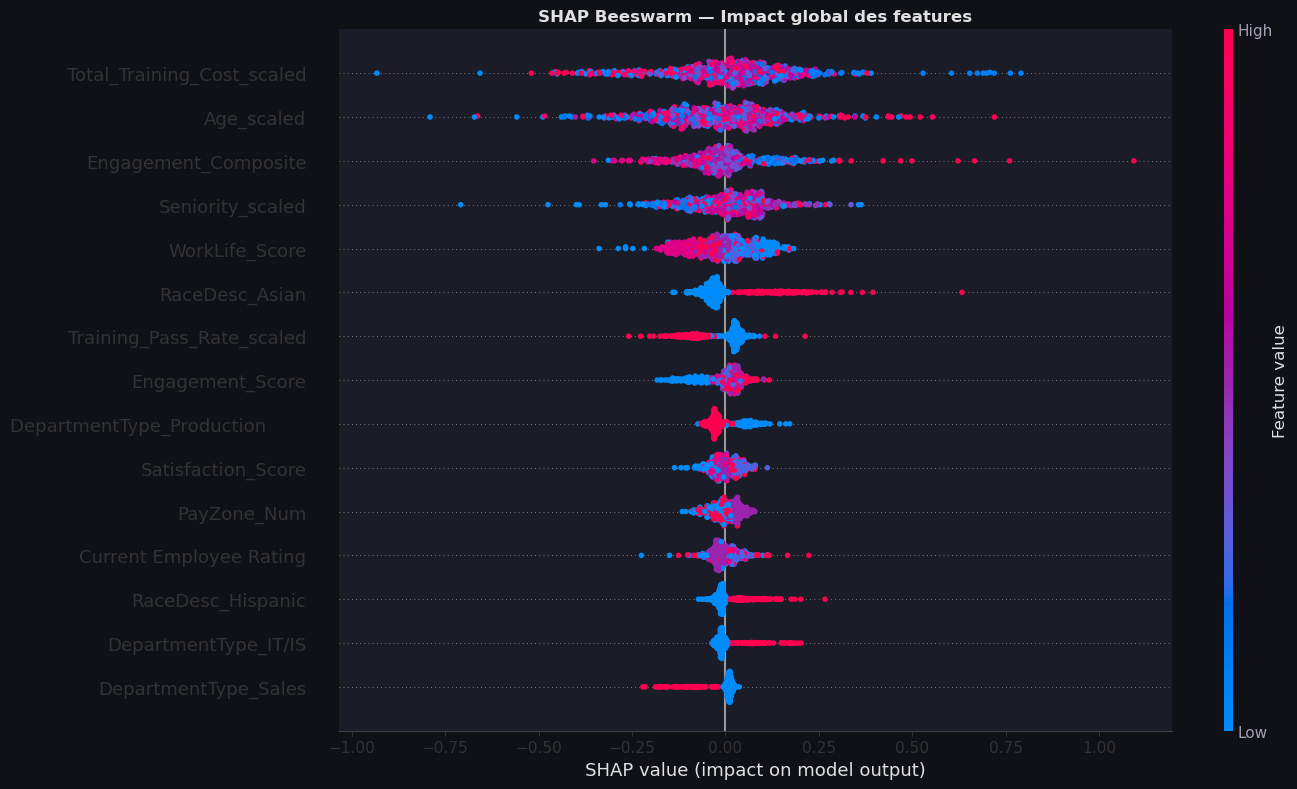

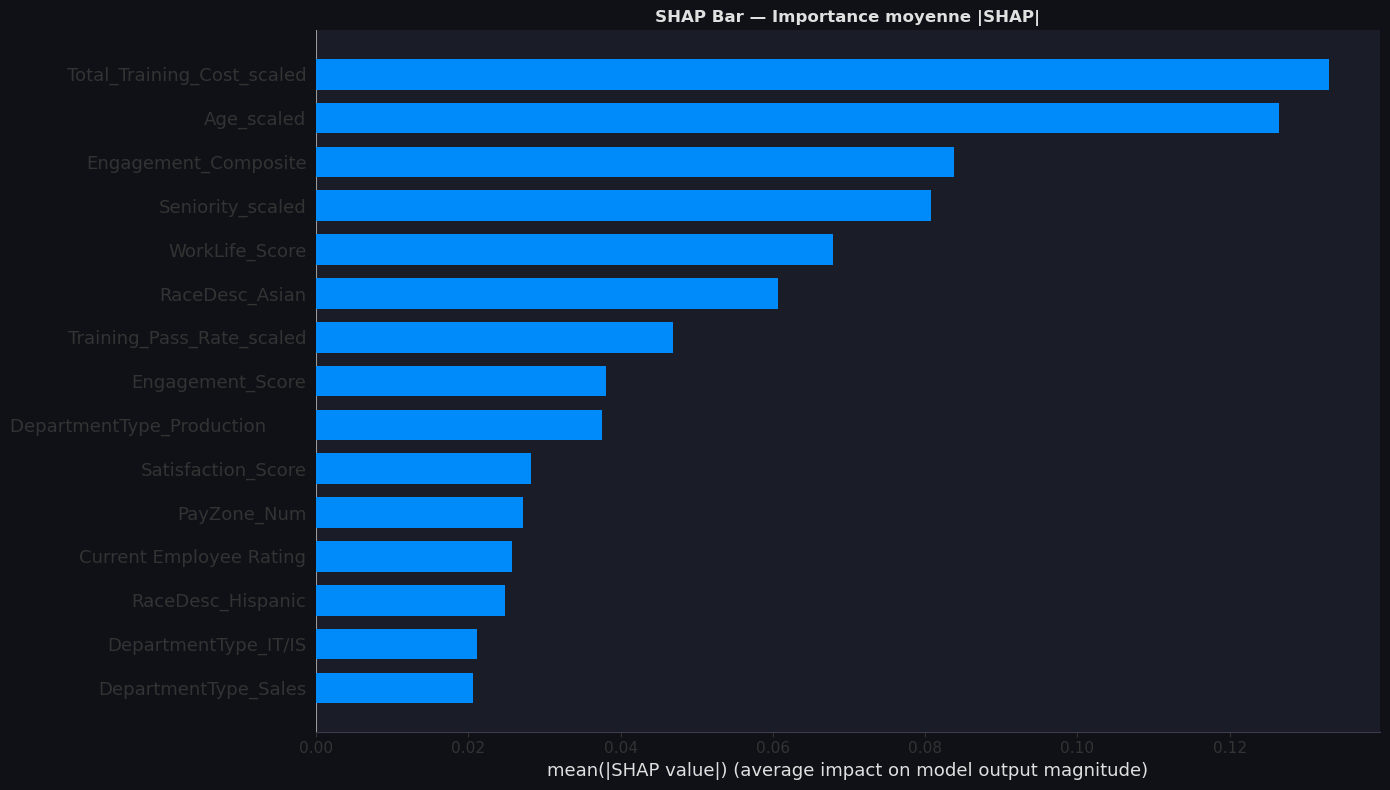

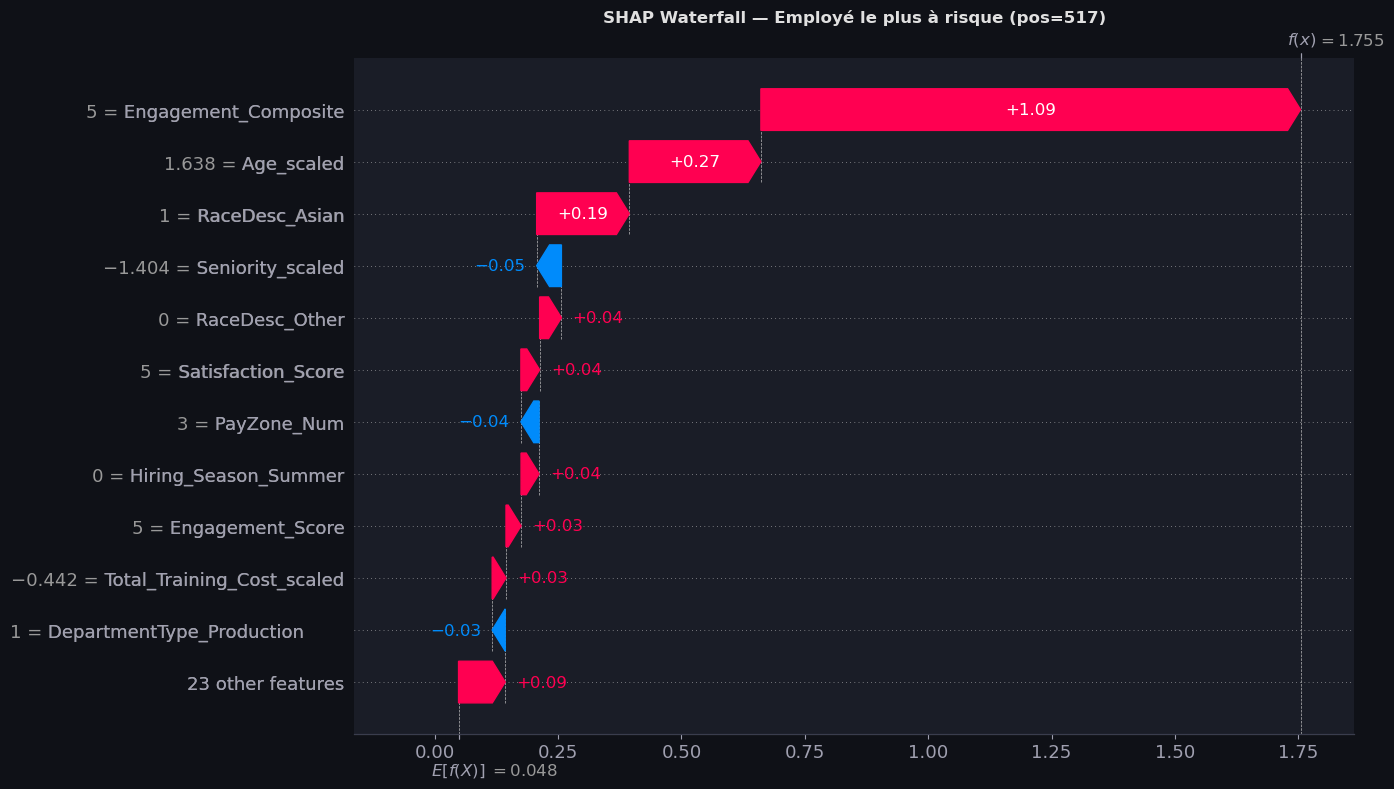

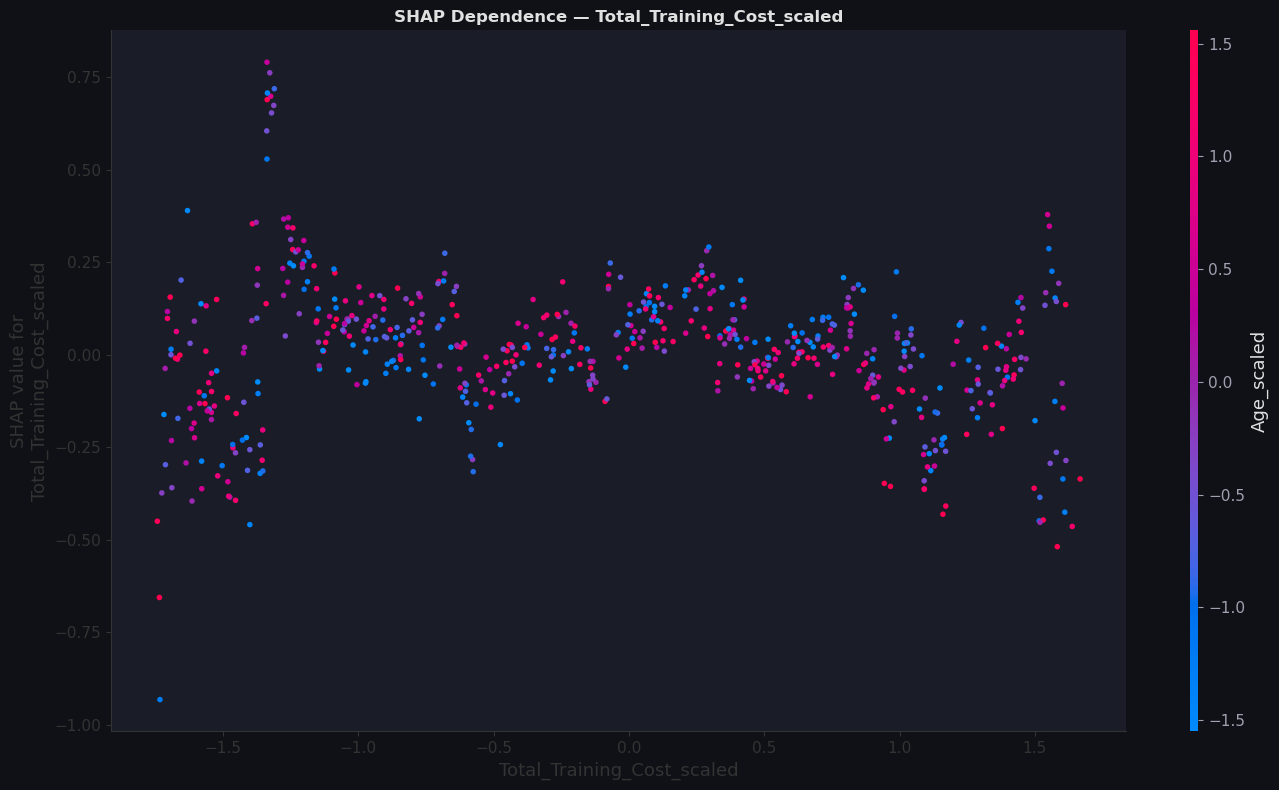

In [ ]:
import shap

print("Calcul des SHAP values...")

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_new)

# ____________________________________________________________
# Beeswarm plot
# ____________________________________________________________
shap.summary_plot(
    shap_values, X_test_new,
    plot_type="dot",
    max_display=15,
    show=False
)
plt.gcf().set_size_inches(14, 8)
plt.title("SHAP Beeswarm — Impact global des features",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


# ____________________________________________________________
# Bar plot
# ____________________________________________________________
shap.summary_plot(
    shap_values, X_test_new,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.gcf().set_size_inches(14, 8)
plt.title("SHAP Bar — Importance moyenne |SHAP|",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


# ____________________________________________________________
# Waterfall — employé le plus à risque
# ____________________________________________________________
row_position = np.argmax(best_model.predict_proba(X_test_new)[:, 1])

shap_explanation = shap.Explanation(
    values        = shap_values[row_position],
    base_values   = explainer.expected_value,
    data          = X_test_new.iloc[row_position],
    feature_names = X_test_new.columns.tolist()
)
shap.waterfall_plot(shap_explanation, max_display=12, show=False)
plt.gcf().set_size_inches(14, 8)
plt.title(f"SHAP Waterfall — Employé le plus à risque (pos={row_position})",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


# ____________________________________________________________
# 4. Dependence plot — top feature
# ____________________________________________________________
top_feature = X_test_new.columns[np.abs(shap_values).mean(axis=0).argmax()]

fig, ax = plt.subplots(figsize=(14, 8))
shap.dependence_plot(
    top_feature, shap_values, X_test_new,
    ax=ax, show=False
)
ax.set_title(f"SHAP Dependence — {top_feature}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Rapport final

In [20]:
print("\n" + "="*60)
print(" RAPPORT FINAL — MODÈLE D'ATTRITION")
print("="*60)
for name, res in results.items():
    print(f"\n  {name}")
    print(f"    AUC ROC   : {res['auc']:.3f}")
    print(f"    Avg Prec  : {res['ap']:.3f}")
    print(f"    CV AUC    : {res['cv_mean']:.3f} ± {res['cv_std']:.3f}")
    print(classification_report(y_test_new, res["y_pred"],
                                target_names=["Actif","Départ"],
                                digits=3))

print(f"\n🏆 Meilleur modèle : {best_name}")
print(f"\n📊 Répartition des risques (employés actifs) :")
active_risk = master[master["Is_Active"] == True]["Risk_Level"].value_counts()
for level, count in active_risk.items():
    pct = count / active_risk.sum() * 100
    print(f"   {level:<10} : {count:>4} employés ({pct:.1f}%)")

print("="*60)

master.to_csv("master_hr_final.csv", index=False)
print("\n master_hr_final.csv exporté — projet complet !")


 RAPPORT FINAL — MODÈLE D'ATTRITION

  Random Forest
    AUC ROC   : 0.424
    Avg Prec  : 0.456
    CV AUC    : 0.473 ± 0.029
              precision    recall  f1-score   support

       Actif      0.439     0.457     0.448       293
      Départ      0.461     0.443     0.452       307

    accuracy                          0.450       600
   macro avg      0.450     0.450     0.450       600
weighted avg      0.450     0.450     0.450       600


  Gradient Boosting
    AUC ROC   : 0.453
    Avg Prec  : 0.468
    CV AUC    : 0.475 ± 0.019
              precision    recall  f1-score   support

       Actif      0.465     0.430     0.447       293
      Départ      0.492     0.528     0.509       307

    accuracy                          0.480       600
   macro avg      0.479     0.479     0.478       600
weighted avg      0.479     0.480     0.479       600


  Logistic Regression
    AUC ROC   : 0.443
    Avg Prec  : 0.471
    CV AUC    : 0.497 ± 0.031
              precision   